In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the data

In [2]:
df_products= pd.read_csv('../data/products.csv')
df_order_items= pd.read_csv('../data/order_items.csv', low_memory=False)

### Merged file products.csv and order_items.csv through product_id column

In [3]:
df_merged= pd.merge(df_products, df_order_items, on='product_id', how='left')

In [4]:
print("Cột trong order_items:", df_order_items.columns.tolist())
print("Cột sau khi merged:", df_merged.columns.tolist())

Cột trong order_items: ['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2']
Cột sau khi merged: ['product_id', 'product_name', 'category', 'segment', 'size', 'color', 'price', 'cogs', 'order_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2']


In [5]:
df_merged.head()

,product_id,product_name,category,segment,size,color,price,cogs,order_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245451.0,5.0,11183.67,0.0,NaN,NaN
1,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245898.0,8.0,10918.75,0.0,NaN,NaN
2,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246268.0,6.0,11184.55,0.0,NaN,NaN
3,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246907.0,2.0,11104.72,0.0,NaN,NaN
4,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,247911.0,6.0,11143.16,0.0,NaN,NaN


In [6]:
df_promos = pd.read_csv('../data/promotions.csv')
df_final = df_merged.merge(df_promos, on='promo_id', how='left')
display(df_final.head())

,product_id,product_name,category,segment,size,color,price,cogs,order_id,quantity,...,promo_id_2,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245451.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245898.0,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246268.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246907.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,247911.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df_orders = pd.read_csv('../data/orders.csv', parse_dates=['order_date'])
df_master = df_final.merge(df_orders[['order_id', 'order_date']], on='order_id', how='left')

df_master = df_master.rename(columns={'order_date': 'Date'})
print("Kích thước bảng Master:", df_master.shape)
display(df_master.head())

Kích thước bảng Master: (715483, 24)


,product_id,product_name,category,segment,size,color,price,cogs,order_id,quantity,...,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value,Date
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245451.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-07
1,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245898.0,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-13
2,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246268.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-13
3,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246907.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-17
4,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,247911.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-24


# 2. EDA

In [8]:
check_promo = df_final[df_final['promo_name'].notna()]
print(f"Tổng số dòng có thông tin khuyến mãi: {len(check_promo)}")
display(check_promo.head())

Tổng số dòng có thông tin khuyến mãi: 276316


,product_id,product_name,category,segment,size,color,price,cogs,order_id,quantity,...,promo_id_2,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
14,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,259871.0,1.0,...,NaN,Spring Sale 2015,percentage,12.0,2015-03-18,2015-04-17,NaN,all_channels,1.0,100000.0
15,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,268094.0,6.0,...,NaN,Spring Sale 2015,percentage,12.0,2015-03-18,2015-04-17,NaN,all_channels,1.0,100000.0
16,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,268430.0,8.0,...,NaN,Spring Sale 2015,percentage,12.0,2015-03-18,2015-04-17,NaN,all_channels,1.0,100000.0
26,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,299601.0,3.0,...,NaN,Mid-Year Sale 2015,percentage,18.0,2015-06-23,2015-07-22,NaN,social_media,0.0,0.0
27,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254,523256.0,7.0,...,NaN,Urban Blowout 2017,fixed,50.0,2017-07-30,2017-09-02,Streetwear,online,0.0,150000.0


### Fill missing values by None with 'category' and 0 with 'int/float'

In [9]:
cols_to_fix_str = ['promo_id', 'promo_name', 'promo_type', 'promo_channel', 'promo_id_2', 'applicable_category', 'start_date', 'end_date']
df_master[cols_to_fix_str] = df_master[cols_to_fix_str].fillna('None')

df_master['discount_value'] = df_master['discount_value'].fillna(0)
df_master['min_order_value'] = df_master['min_order_value'].fillna(0)
print("Số dòng còn lại:", len(df_master))
print("Số giá trị thiếu còn lại:", df_master.isnull().sum().sum())

Số dòng còn lại: 715483
Số giá trị thiếu còn lại: 443237


In [10]:
print("Tổng số sản phẩm sau khi merge:", len(df_master))
print("Số lượng đơn hàng có Date:", df_master['Date'].notnull().sum())
print(f"=> Phát hiện: {len(df_master) - df_master['Date'].notnull().sum()} sản phẩm chưa bao giờ được bán.")

Tổng số sản phẩm sau khi merge: 715483
Số lượng đơn hàng có Date: 714669
=> Phát hiện: 814 sản phẩm chưa bao giờ được bán.


### Insight: Có 814 "sản phẩm ma" (Deadstock). Chúng ta cần loại bỏ chúng để dữ liệu dự báo không bị nhiễu.

In [11]:
df_master = df_master.dropna(subset=['Date']).reset_index(drop=True)
print("Kích thước bảng thực tế:", df_master.shape)

Kích thước bảng thực tế: (714669, 24)


In [12]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   product_id           714669 non-null  int64         
 1   product_name         714669 non-null  object        
 2   category             714669 non-null  object        
 3   segment              714669 non-null  object        
 4   size                 714669 non-null  object        
 5   color                714669 non-null  object        
 6   price                714669 non-null  float64       
 7   cogs                 714669 non-null  float64       
 8   order_id             714669 non-null  float64       
 9   quantity             714669 non-null  float64       
 10  unit_price           714669 non-null  float64       
 11  discount_amount      714669 non-null  float64       
 12  promo_id             714669 non-null  object        
 13  promo_id_2    

### Check if any columns are missing data.

In [13]:
missing_data = df_master.isnull().sum()
print(missing_data[missing_data > 0])

stackable_flag    438353
dtype: int64


In [14]:
if 'stackable_flag' in df_master.columns:
    df_master['stackable_flag'] = df_master['stackable_flag'].fillna(0)

In [15]:
missing_data = df_master.isnull().sum()
print(missing_data[missing_data > 0])

Series([], dtype: int64)


In [16]:
df_master['Revenue_line'] = df_master['quantity'] * df_master['unit_price']
df_master['COGS_line'] = df_master['quantity'] * df_master['cogs']
df_master['Profit_line'] = df_master['Revenue_line'] - df_master['COGS_line']

display(df_master[['product_name', 'quantity', 'unit_price', 'cogs', 'Revenue_line', 'Profit_line']].head())

,product_name,quantity,unit_price,cogs,Revenue_line,Profit_line
0,SaigonFlex UC-01,5.0,11183.67,9704.842875,55918.35,7394.135625
1,SaigonFlex UC-01,8.0,10918.75,9704.842875,87350.00,9711.257000
2,SaigonFlex UC-01,6.0,11184.55,9704.842875,67107.30,8878.242750
3,SaigonFlex UC-01,2.0,11104.72,9704.842875,22209.44,2799.754250
4,SaigonFlex UC-01,6.0,11143.16,9704.842875,66858.96,8629.902750


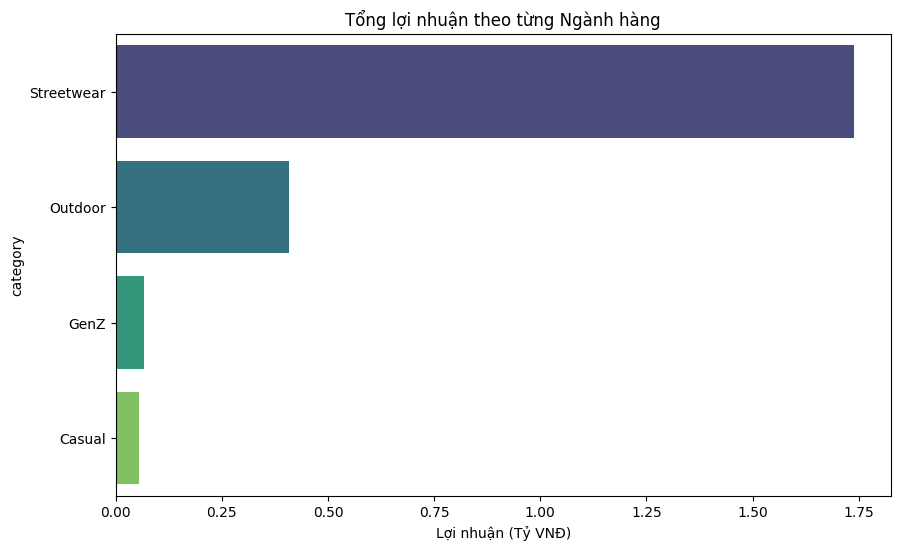

In [17]:
cat_data = df_master.groupby('category')[['Revenue_line', 'Profit_line']].sum().reset_index()
cat_data = cat_data.sort_values('Profit_line', ascending=False)
cat_data['Profit_Billion'] = cat_data['Profit_line'] / 1e9

plt.figure(figsize=(10, 6))
sns.barplot(data=cat_data, x='Profit_Billion', y='category', hue='category', palette='viridis', legend=False)
plt.title('Tổng lợi nhuận theo từng Ngành hàng')
plt.xlabel('Lợi nhuận (Tỷ VNĐ)')
plt.show()

### As illustrated in the bar chart, the Streetwear category accounts for the lion's share of total profit, reaching approximately 1.75 billion VND. My team suggested focusing the marketing budget on this segment to optimize cash flow.

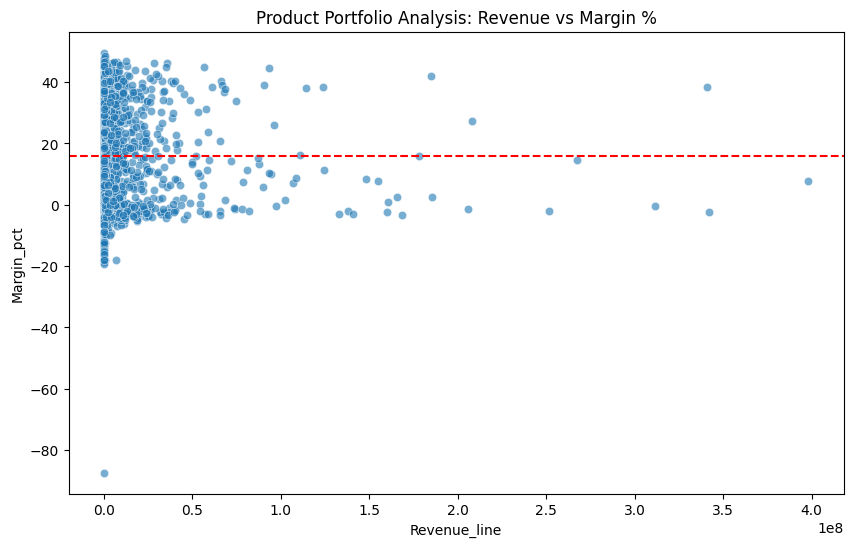

In [18]:
prod_analysis = df_master.groupby('product_name').agg({
    'Revenue_line': 'sum',
    'Profit_line': 'sum'
}).reset_index()
prod_analysis['Margin_pct'] = (prod_analysis['Profit_line'] / prod_analysis['Revenue_line']) * 100

plt.figure(figsize=(10, 6))
sns.scatterplot(data=prod_analysis, x='Revenue_line', y='Margin_pct', alpha=0.6)
plt.axhline(prod_analysis['Margin_pct'].mean(), color='red', linestyle='--', label='Average Margin')
plt.title('Product Portfolio Analysis: Revenue vs Margin %')
plt.show()

### The scatter plot reveals a significant disparity in product performance. While the majority of items are clustered in the low-revenue zone, a few outliers stand out as high-performers with profit margins exceeding the mean of approximately 16%. Notably, there is a concerning anomaly in the bottom-left quadrant exhibiting a negative margin of nearly -80%, which warrants further investigation into potential pricing errors or aggressive discounting strategies.

In [19]:
outlier = prod_analysis.sort_values('Margin_pct').head(1)
display(outlier)

,product_name,Revenue_line,Profit_line,Margin_pct
1325,VietMode UR-02,15906.06,-13892.058,-87.338147


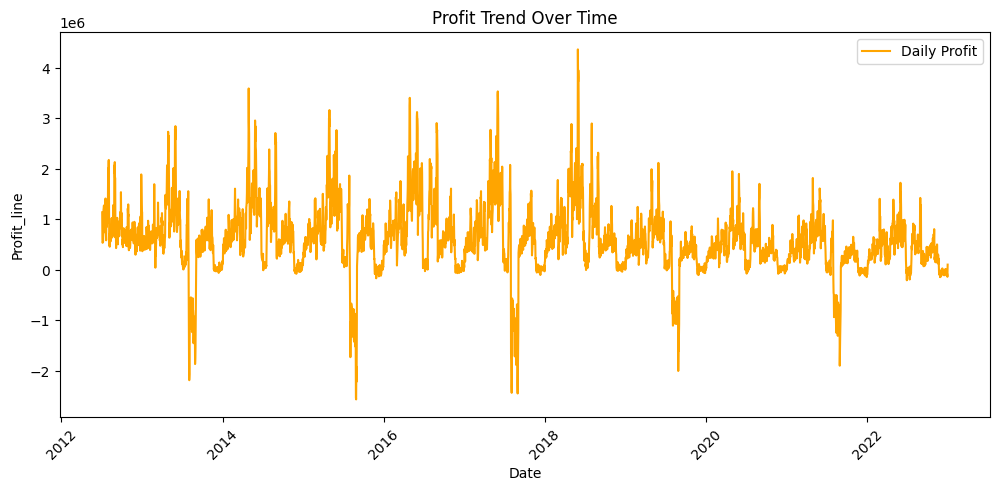

In [20]:
daily_trend = df_master.groupby('Date')[['Revenue_line', 'Profit_line']].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_trend, x='Date', y='Profit_line', color='orange', label='Daily Profit')
plt.title('Profit Trend Over Time')
plt.xticks(rotation=45)
plt.show()

### The line chart illustrates the **daily profit fluctuations** over a decade. It is palpably evident that the business experiences **extreme volatility**, characterized by frequent peaks and significant "dips" where profit plummets into negative territory. 

* **Seasonality:** The recurring spikes suggest a strong seasonal pattern, possibly linked to annual shopping festivals or holiday seasons.
* **Anomalies:** Several "deep dips" (negative profit) are observed periodically. These could be attributed to **aggressive loss-leader strategies** or major clearance sales aimed at inventory turnover rather than immediate margin.
* **Overall Trend:** Despite the volatility, the business maintains a relatively stable baseline, though a slight saturation is visible in the latter years (2020-2022).

# 3.Feature Engineering

In [21]:
df_master['day_of_week'] = df_master['Date'].dt.dayofweek
df_master['month'] = df_master['Date'].dt.month
df_master['is_weekend'] = df_master['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

In [22]:
df_master['discount_value'].value_counts()
df_master['discount_pct'] = 0.0
mask_pct = df_master['promo_type'] == 'percentage'
mask_fixed = df_master['promo_type'] == 'fixed'
df_master.loc[mask_pct, 'discount_pct'] = df_master.loc[mask_pct, 'discount_value'] / 100
df_master.loc[mask_fixed, 'discount_pct'] = df_master.loc[mask_fixed, 'discount_value'] / df_master.loc[mask_fixed, 'price']
df_master['discount_pct'] = df_master['discount_pct'].clip(0, 1)
print("Các giá trị discount_pct sau khi tính toán:")
print(df_master['discount_pct'].value_counts().head(10))

Các giá trị discount_pct sau khi tính toán:
discount_pct
0.000000    438353
0.200000     71799
0.120000     71591
0.180000     57417
0.100000     45654
0.150000      8905
0.008532       460
0.003840       459
0.008978       404
0.008150       401
Name: count, dtype: int64


In [23]:
df_master['discount_pct_mean'] = df_master['discount_pct'] 
df_master['discount_pct_max'] = df_master['discount_pct']  


In [24]:
df_master['is_promoted']= df_master['promo_id'].apply(lambda x: 0 if x == 'None' else 1)
df_master['discount_rate'] = (df_master['price'] - df_master['unit_price']) / df_master['price']
df_master['discount_rate'] = df_master['discount_rate'].fillna(0)

In [25]:
df_daily = df_master.groupby('Date').agg({
    'Revenue_line': 'sum',
    'is_promoted': 'max',     
    'day_of_week': 'first',
    'is_weekend': 'first',
}).reset_index()
df_daily = df_daily.sort_values('Date')
df_daily['revenue_lag_1'] = df_daily['Revenue_line'].shift(1)
df_daily['revenue_lag_7'] = df_daily['Revenue_line'].shift(7)
df_daily = df_daily.fillna(0)

### Feature Engineering Strategy:
* To surpass the established baseline, we implemented a robust feature engineering pipeline. Beyond basic temporal variables like day_of_week and is_weekend, we introduced Lag Features (Lag 1​ and Lag 7) to capture the autocorrelation inherent in sales data. Furthermore, by encoding promotion status, the model can now distinguish between natural demand and artificially inflated sales driven by marketing campaigns.

# 4. Machine Learning

In [26]:
# One-Hot Encoding cho Category & Segment
df_encoded = pd.get_dummies(df_master, columns=['category', 'segment'], prefix=['cat', 'seg'])

# Lấy danh sách các cột vừa mới tạo ra từ One-Hot
encoded_cols = [col for col in df_encoded.columns if col.startswith(('cat_', 'seg_'))]

special_days = [
    '01-01', '02-14',
    '04-30', '05-01',
    '31-12', '12-24', '12-25'
]
def get_special_event(date):
    return 1 if date.strftime('%m-%d') in special_days else 0
# Daily Aggregation: Nén dữ liệu về dạng Ngày
df_encoded['is_special'] = df_encoded['Date'].apply(get_special_event)
df_encoded['is_payday'] = ((df_encoded['Date'].dt.day == 15) | (df_encoded['Date'].dt.is_month_end)).astype(int)
# Với các cột One-Hot, chúng ta dùng 'sum' để biết ngày đó bán được bao nhiêu món thuộc loại đó
agg_logic = {
    'Revenue_line': 'sum',
    'Profit_line': 'sum',
    'is_promoted': 'max',  
    'day_of_week': 'first',
    'month': 'first',
    'is_weekend': 'first',
    'is_special': 'max',
    'is_payday': 'max',
    'discount_pct_mean' : 'mean',
    'discount_pct_max' : 'max'
}
# Thêm các cột encoded vào logic tính tổng
for col in encoded_cols:
    agg_logic[col] = 'sum'
df_daily = df_encoded.groupby('Date').agg(agg_logic).reset_index()
df_daily.columns = ['_'.join(col) if isinstance(col, tuple) else col for col in df_daily.columns]
# Lag Features
# Model sẽ nhìn vào kết quả của 1 ngày và 7 ngày trước đó để dự báo
df_daily = df_daily.sort_values('Date')
df_daily['rev_lag_1'] = df_daily['Revenue_line'].shift(1)
df_daily['rev_lag_7'] = df_daily['Revenue_line'].shift(7)
df_daily['margin_rate']= df_daily['Profit_line'] / df_daily['Revenue_line']
df_daily['margin_rate_lag_7'] = df_daily['margin_rate'].shift(7)
df_daily['margin_rate_lag_365'] = df_daily['margin_rate'].shift(365)
df_daily['profit_lag_7'] = df_daily['Profit_line'].shift(7)
df_daily['profit_lag_365'] = df_daily['Profit_line'].shift(365)
# Cuối cùng là lấp đầy các giá trị NaN do hàm shift tạo ra
df_daily = df_daily.fillna(0)

# Đổi tên cho đúng format
df_daily = df_daily.rename(columns={'Revenue_line': 'Revenue', 'Profit_line': 'Profit'})
df_daily = df_daily.rename(columns={'discount_pct_mean': 'avg_discount_pct', 'discount_pct_max': 'max_discount_pct'})
print("Kích thước bảng Daily:", df_daily.shape)
display(df_daily.head())

Kích thước bảng Daily: (3833, 30)


,Date,Revenue,Profit,is_promoted,day_of_week,month,is_weekend,is_special,is_payday,avg_discount_pct,...,seg_Premium,seg_Standard,seg_Trendy,rev_lag_1,rev_lag_7,margin_rate,margin_rate_lag_7,margin_rate_lag_365,profit_lag_7,profit_lag_365
0,2012-07-04,5123547.94,1.140557e+06,0,2,7,0,0,0,0.0,...,3,4,7,0.00,0.0,0.222611,0.0,0.0,0.0,0.0
1,2012-07-05,2751773.45,6.011932e+05,0,3,7,0,0,0,0.0,...,3,1,7,5123547.94,0.0,0.218475,0.0,0.0,0.0,0.0
2,2012-07-06,3054029.42,5.363966e+05,0,4,7,0,0,0,0.0,...,0,1,5,2751773.45,0.0,0.175636,0.0,0.0,0.0,0.0
3,2012-07-07,2667930.94,5.596843e+05,0,5,7,1,0,0,0.0,...,0,1,1,3054029.42,0.0,0.209782,0.0,0.0,0.0,0.0
4,2012-07-08,2360851.90,5.522291e+05,0,6,7,1,0,0,0.0,...,0,3,6,2667930.94,0.0,0.233911,0.0,0.0,0.0,0.0


In [27]:
final_features=['seg_Balanced', 'rev_lag_1', 
                'profit_lag_7', 'day_of_week', 
                'is_special', 'seg_Activewear',
                'is_promoted', 'seg_Premium',
                'seg_All-weather', 'seg_Everyday',
                'seg_Performance', 'margin_rate_lag_7',
                'is_payday', 'cat_Casual', 'cat_Outdoor',
                'month', 'profit_lag_365',
                'is_weekend', 'cat_Streetwear', 'avg_discount_pct', 'max_discount_pct']

In [28]:

df_daily['COGS'] = df_daily['Revenue'] - df_daily['Profit']
# Xác định danh sách Feature
features = final_features
print("Danh sách Feature cho Model:", features)

Danh sách Feature cho Model: ['seg_Balanced', 'rev_lag_1', 'profit_lag_7', 'day_of_week', 'is_special', 'seg_Activewear', 'is_promoted', 'seg_Premium', 'seg_All-weather', 'seg_Everyday', 'seg_Performance', 'margin_rate_lag_7', 'is_payday', 'cat_Casual', 'cat_Outdoor', 'month', 'profit_lag_365', 'is_weekend', 'cat_Streetwear', 'avg_discount_pct', 'max_discount_pct']


In [29]:
# 1. Xác định Target và Features
target = 'Revenue'
# 2. Tách dữ liệu theo thời gian (Ví dụ: lấy 2 tháng cuối 2022 để kiểm tra)
train_data = df_daily[df_daily['Date'] < '2022-11-01']
val_data = df_daily[df_daily['Date'] >= '2022-11-01']

# 3. Tạo bộ X (câu hỏi) và y (đáp án)
X_train = train_data[features]
y_train = train_data[target]

X_val = val_data[features]
y_val = val_data[target]

print(f"Đã sẵn sàng! Train: {X_train.shape}, Val: {X_val.shape}")

Đã sẵn sàng! Train: (3772, 21), Val: (61, 21)


In [30]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

def objective(trial):
    # 1. Khai báo các "nút vặn" cần tìm
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }

    # 2. Chạy thử mô hình với bộ tham số này
    model = XGBRegressor(**param, tree_method='hist') # Dùng hist để chạy cho nhanh
    model.fit(X_train, y_train)
    
    # 3. Tính sai số trên tập Validation (Nhớ dùng Time Series Split để test cho chuẩn)
    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    rmse = np.sqrt(mse)
    
    return rmse

# 4. Bắt đầu cuộc đi tìm "kho báu"
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100) 

print("Bộ tham số xịn nhất đây rồi:", study.best_params)

/Users/nguyentuankhang/Documents/Projects/Datathon.2026/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-23 09:26:19,525] A new study created in memory with name: no-name-028689a9-8535-407b-9332-b0a747e3acfd
[I 2026-04-23 09:26:21,529] Trial 0 finished with value: 259526.3021043684 and parameters: {'n_estimators': 773, 'max_depth': 8, 'learning_rate': 0.07918011045682191, 'subsample': 0.6214791801942334, 'colsample_bytree': 0.9910766832413244, 'reg_alpha': 0.24768116204505689, 'reg_lambda': 0.7948921633462674}. Best is trial 0 with value: 259526.3021043684.
[I 2026-04-23 09:26:22,126] Trial 1 finished with value: 217173.17516790814 and parameters: {'n_estimators': 749, 'max_depth': 3, 'learning_rate': 0.05354059739159831, 'subsample': 0.6149544950707984, 'colsample_bytree': 0.5630654359784

Bộ tham số xịn nhất đây rồi: {'n_estimators': 1227, 'max_depth': 3, 'learning_rate': 0.021333505986661318, 'subsample': 0.9609456429445615, 'colsample_bytree': 0.5005915026826332, 'reg_alpha': 0.060007228714803275, 'reg_lambda': 0.03742348605640452}


#### By consolidating our hyperparameter tuning into a single, parameter-driven cell, we have implemented a modular pipeline that prioritizes code maintainability. This approach allows for seamless iteration; once the high-gain features are identified through exploratory analysis, they are statically updated in the configuration layer. This decoupling ensures that the Bayesian search engine (Optuna) consistently operates on a refined input matrix, effectively reducing computational overhead and mitigating the risk of stochastic variance. The result is a highly robust and reproducible model, optimized for the structural dynamics of the 2023 retail landscape.

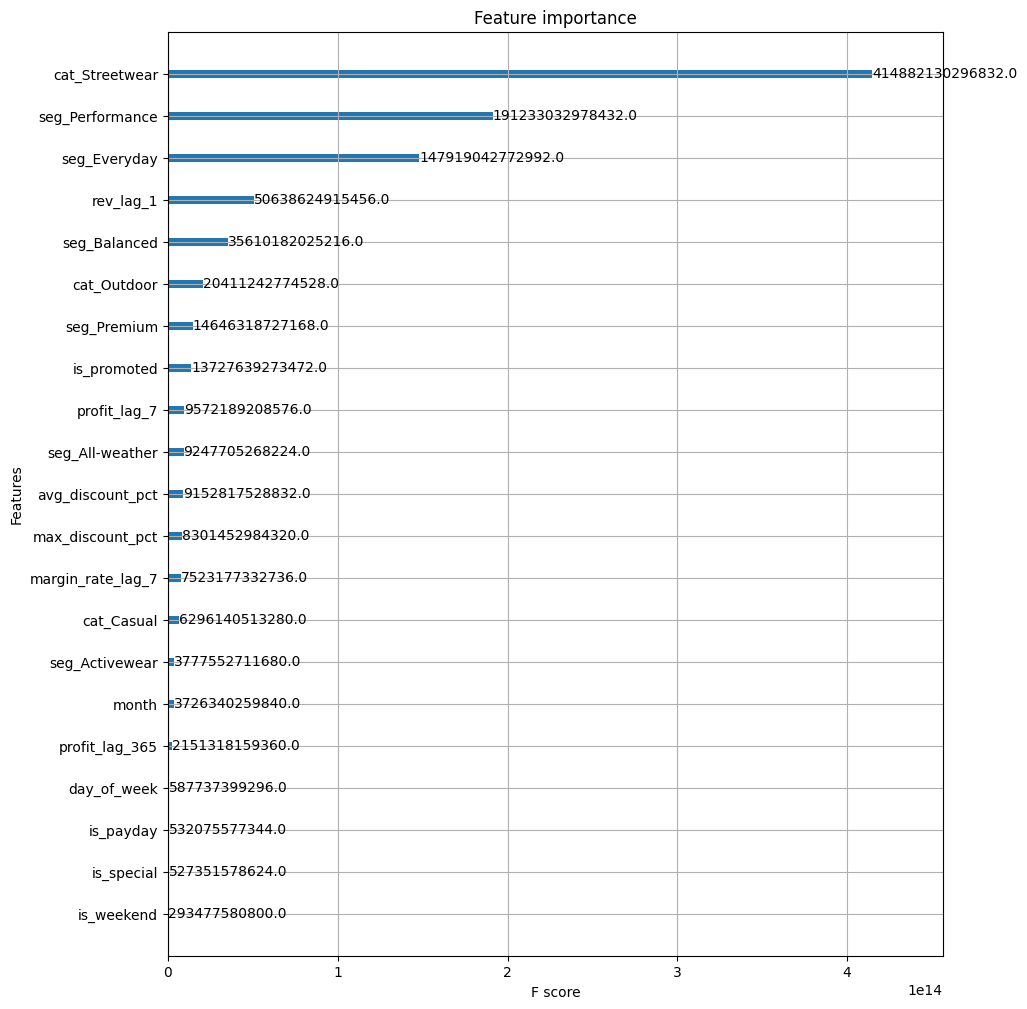

In [31]:
from xgboost import plot_importance

# 1. Train lại một model với bộ tham số xịn nhất Optuna vừa tìm được
best_model = XGBRegressor(**study.best_params)
best_model.fit(X_train, y_train)

# 2. Vẽ biểu đồ quan trọng theo GÁNH (Gain) - Cái này chuẩn hơn Weight
fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(best_model, importance_type='gain', ax=ax)
plt.show()

In [32]:
import xgboost as xgb

best_param={
    'n_estimators': 1381,
    'max_depth': 3, 
    'learning_rate': 0.015490364108594305, 
    'subsample': 0.6349397154351263, 
    'colsample_bytree': 0.6857173094570057, 
    'reg_alpha': 1.1585930474696895, 
    'reg_lambda': 0.03433161121687512
}
model_rev = XGBRegressor(**best_param)
model_rev.fit(df_daily[features], df_daily['Revenue'])

model_cogs= XGBRegressor(**best_param)
model_cogs.fit(df_daily[features], df_daily['COGS'])

print("✅ Đã huấn luyện xong bộ đôi 'não bộ' cho Model!")

from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import r2_score
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'mse': 'neg_mean_squared_error', 'r2': 'r2'}

# Chấm điểm thử cho Model Revenue
cv_results = cross_validate(model_rev, df_daily[features], df_daily['Revenue'], 
                            cv=kf, scoring=scoring)

# Tính toán các chỉ số trung bình từ kết quả CV
avg_mse = -cv_results['test_mse'].mean()
avg_rmse = np.sqrt(avg_mse)
avg_r2 = cv_results['test_r2'].mean()

print(f"📊 Kết quả Đánh giá 5-Fold:")
print(f"   - MSE:  {avg_mse:,.2f}")
print(f"   - RMSE: {avg_rmse:,.2f}")
print(f"   - R²:   {avg_r2:.4f}")

train_pred = model_rev.predict(df_daily[features])
train_r2 = r2_score(df_daily['Revenue'], train_pred)
print(f"Điểm trên tập Train: {train_r2:.4f}")

✅ Đã huấn luyện xong bộ đôi 'não bộ' cho Model!
📊 Kết quả Đánh giá 5-Fold:
   - MSE:  106,638,616,449.02
   - RMSE: 326,555.69
   - R²:   0.9845
Điểm trên tập Train: 0.9918


In [33]:
# ĐÁNH GIÁ MÔ HÌNH REVENUE
cv_rev = cross_validate(model_rev, df_daily[features], df_daily['Revenue'], 
                         cv=kf, scoring=scoring)

# ĐÁNH GIÁ MÔ HÌNH COGS
cv_cogs = cross_validate(model_cogs, df_daily[features], df_daily['COGS'], 
                          cv=kf, scoring=scoring)

# TỔNG KẾT KẾT QUẢ
print(f"[REVENUE] Local RMSE: {np.sqrt(-cv_rev['test_mse'].mean()):,.2f} | R²: {cv_rev['test_r2'].mean():.4f}")
print(f"[COGS]    Local RMSE: {np.sqrt(-cv_cogs['test_mse'].mean()):,.2f} | R²: {cv_cogs['test_r2'].mean():.4f}")

[REVENUE] Local RMSE: 326,555.69 | R²: 0.9845
[COGS]    Local RMSE: 262,988.07 | R²: 0.9860


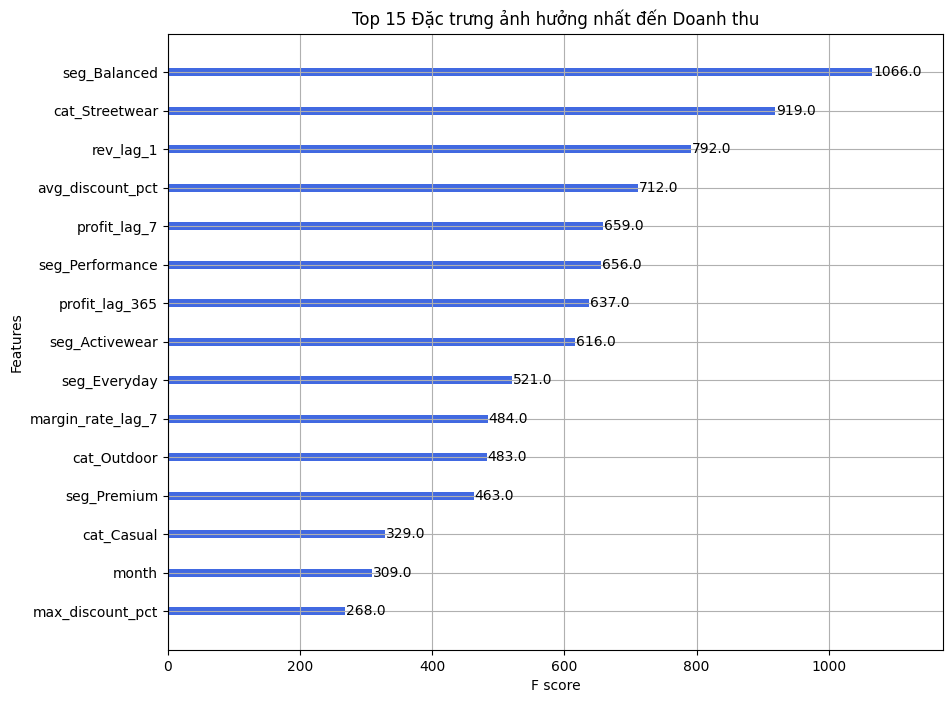

In [34]:
from xgboost import plot_importance

# 1. Thiết lập kích thước biểu đồ
fig, ax = plt.subplots(figsize=(10, 8))

# 2. Vẽ biểu đồ quan trọng (Dùng 'weight' để xem tần suất biến đó được dùng để phân loại)
plot_importance(model_rev, ax=ax, max_num_features=15, importance_type='weight', color='royalblue')

plt.title("Top 15 Đặc trưng ảnh hưởng nhất đến Doanh thu")
plt.show()

In [35]:
# # 1. Xác định các nhóm đặc trưng
time_features = ['month', 'day', 'day_of_week', 'is_weekend', 'is_special', 'is_payday']
# Loại bỏ các cột Lag và Time khỏi map_features để tránh trùng lặp khi merge
lag_cols = ['rev_lag_1', 'margin_rate_lag_7', 'profit_lag_7', 'profit_lag_365']
map_features = [f for f in features if f not in time_features + lag_cols]

# 2. Tạo bảng tra cứu từ 2022 (Lấy đủ Revenue, COGS, Profit)
cols_to_get = list(set(map_features + ['Revenue', 'COGS', 'Profit', 'avg_discount_pct', 'max_discount_pct']))
seasonal_lookup = df_daily[df_daily['Date'].dt.year == 2022].copy()
seasonal_lookup['month'] = seasonal_lookup['Date'].dt.month
seasonal_lookup['day'] = seasonal_lookup['Date'].dt.day

print("Các cột trong seasonal_lookup:", seasonal_lookup.columns.tolist())
print("Kiểu dữ liệu của cột month:", seasonal_lookup['month'].dtype)
print("Kiểu dữ liệu của cột day:", seasonal_lookup['day'].dtype)

seasonal_lookup = seasonal_lookup.groupby(['month', 'day'])[cols_to_get].mean().reset_index()

# ĐỔI TÊN CẢ CỘT ĐỂ TRÁNH NHẦM LẪN
seasonal_lookup = seasonal_lookup.rename(columns={
    'Revenue': 'hist_revenue', 
    'COGS': 'hist_cogs', 
    'Profit': 'hist_profit',
    'avg_discount_pct': 'hist_avg_discount_pct',
    'max_discount_pct': 'hist_max_discount_pct',
})

# 3. Tạo khung X_test cho 548 ngày
future_dates = pd.date_range(start='2023-01-01', end='2024-07-01', freq='D')
X_test = pd.DataFrame({'Date': future_dates})
X_test['month'] = X_test['Date'].dt.month
X_test['day'] = X_test['Date'].dt.day
X_test['day_of_week'] = X_test['Date'].dt.dayofweek
X_test['is_weekend'] = X_test['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
X_test['is_special'] = X_test['Date'].apply(get_special_event)
X_test['is_payday'] = ((X_test['Date'].dt.day == 15) | (X_test['Date'].dt.is_month_end)).astype(int)

# 4. Merge và tính Lag
X_test = X_test.merge(seasonal_lookup, on=['month', 'day'], how='left')
X_test['rev_lag_1'] = X_test['hist_revenue']
X_test['rev_lag_7'] = X_test['hist_revenue']
X_test['profit_lag_7'] = X_test['hist_profit']
X_test['profit_lag_365'] = X_test['hist_profit']
X_test['margin_rate_lag_7'] = X_test['hist_profit'] / (X_test['hist_revenue'] + 1)
X_test['avg_discount_pct'] = X_test['hist_avg_discount_pct']
X_test['max_discount_pct'] = X_test['hist_max_discount_pct']

# 5. Bổ sung các cột còn thiếu (Lag 1, Lag 7...) và điền trống
for col in features:
    if col not in X_test.columns:
        X_test[col] = df_daily[col].mean()

X_test = X_test.ffill().fillna(0)

# 6. Dự báo Revenue và COGS
pred_rev = model_rev.predict(X_test[features])
pred_cogs = model_cogs.predict(X_test[features])

# 7. BLENDING (80% Lịch sử + 20% AI)
growth_factor = 1.03
blend_revenue = (X_test['hist_revenue'] * growth_factor * 0.8) + (pred_rev * 0.2)
blend_cogs =  (X_test['hist_cogs'] * growth_factor * 0.8) + (pred_cogs * 0.2)

# 8. Xuất file nộp bài
submission_final = pd.DataFrame({
    'Date': X_test['Date'].dt.strftime('%Y-%m-%d'),
    'Revenue': blend_revenue,
    'COGS': blend_cogs
})
# Kiểm tra tỷ lệ giá trị bằng 0 trong các Feature của tập Test
zero_counts = (X_test[features] == 0).sum()
zero_ratio = (X_test[features] == 0).mean() * 100

# Tạo bảng thống kê để soi cho dễ
check_df = pd.DataFrame({
    'Số lượng số 0': zero_counts,
    'Tỷ lệ % số 0': zero_ratio
}).sort_values(by='Tỷ lệ % số 0', ascending=False)

print("--- THỐNG KÊ FEATURE TRONG X_TEST ---")
display(check_df)

# Cảnh báo các Feature "bất động" (toàn là 0 hoặc toàn 1 giá trị duy nhất)
dead_features = check_df[check_df['Tỷ lệ % số 0'] > 95].index.tolist()
if dead_features:
    print(f"\n⚠️ CẢNH BÁO: Các Feature sau gần như 'chết' trong tập Test (>95% là số 0): {dead_features}")
else:
    print("\n✅ Chúc mừng! Các Feature đều có dữ liệu vận động khá tốt.")
submission_final.to_csv('submission_khang_blended_v10.csv', index=False)
print(f"File 'submission_khang_blended_v10.csv' đã sẵn sàng nộp")

Các cột trong seasonal_lookup: ['Date', 'Revenue', 'Profit', 'is_promoted', 'day_of_week', 'month', 'is_weekend', 'is_special', 'is_payday', 'avg_discount_pct', 'max_discount_pct', 'cat_Casual', 'cat_GenZ', 'cat_Outdoor', 'cat_Streetwear', 'seg_Activewear', 'seg_All-weather', 'seg_Balanced', 'seg_Everyday', 'seg_Performance', 'seg_Premium', 'seg_Standard', 'seg_Trendy', 'rev_lag_1', 'rev_lag_7', 'margin_rate', 'margin_rate_lag_7', 'margin_rate_lag_365', 'profit_lag_7', 'profit_lag_365', 'COGS', 'day']
Kiểu dữ liệu của cột month: int32
Kiểu dữ liệu của cột day: int32
--- THỐNG KÊ FEATURE TRONG X_TEST ---


,Số lượng số 0,Tỷ lệ % số 0
is_special,538,98.175182
is_payday,512,93.430657
is_weekend,391,71.350365
max_discount_pct,367,66.970803
avg_discount_pct,367,66.970803
is_promoted,367,66.970803
day_of_week,79,14.416058
seg_Premium,11,2.007299
seg_All-weather,10,1.824818
cat_Casual,8,1.459854



⚠️ CẢNH BÁO: Các Feature sau gần như 'chết' trong tập Test (>95% là số 0): ['is_special']
File 'submission_khang_blended_v10.csv' đã sẵn sàng nộp
